# Q-Learning for Grid-Based Maze Navigation

## Project Overview

This project implements the Q-learning reinforcement learning algorithm in a grid-based maze environment. An agent learns how to move from a starting position to a goal by repeatedly interacting with the environment and receiving rewards or penalties.

The project demonstrates:

* A grid-based maze with walls, a starting state, a goal state, and penalty states
* Four possible actions: up, down, left, and right
* The Q-learning update rule
* Epsilon-greedy exploration
* Tracking of episode rewards, steps, success rate, and Q-value changes
* Extraction of the learned policy and optimal path
* Comparison of different hyperparameter configurations

The objective is to observe how the agent improves its decisions over multiple training episodes and eventually learns an efficient path through the maze.


In [1]:
# Standard Python libraries
import random
from pathlib import Path

# Numerical operations and data organization
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt

# Improve DataFrame display inside the notebook
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Set random seeds for reproducible results
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Create the output directory if it does not already exist
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Libraries imported successfully.")
print(f"Random seed: {RANDOM_SEED}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Libraries imported successfully.
Random seed: 42
Output directory: C:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_2\Applied_Machine_Intelligence\Project_Q_Learning_Maze_Navigation\outputs


In [2]:
# Define the size of the maze
GRID_ROWS = 5
GRID_COLUMNS = 5

# Define important maze locations
START_STATE = (4, 0)
GOAL_STATE = (0, 4)
TRAP_STATE = (4, 4)

# Define blocked cells that the agent cannot enter
WALLS = {
    (0, 1),
    (1, 1),
    (1, 3),
    (2, 3),
    (3, 1),
    (3, 2),
}

# Define the four possible actions
ACTIONS = {
    0: "UP",
    1: "DOWN",
    2: "LEFT",
    3: "RIGHT",
}

# Define how each action changes the agent's position
ACTION_MOVES = {
    0: (-1, 0),   # UP
    1: (1, 0),    # DOWN
    2: (0, -1),   # LEFT
    3: (0, 1),    # RIGHT
}

# Define the reward structure
STEP_REWARD = -1
INVALID_MOVE_REWARD = -5
GOAL_REWARD = 100
TRAP_REWARD = -50

# Goal and trap states end an episode
TERMINAL_STATES = {GOAL_STATE, TRAP_STATE}

# Create a list of all valid states, excluding walls
VALID_STATES = [
    (row, column)
    for row in range(GRID_ROWS)
    for column in range(GRID_COLUMNS)
    if (row, column) not in WALLS
]

# Display the maze configuration
print(f"Grid size: {GRID_ROWS} x {GRID_COLUMNS}")
print(f"Start state: {START_STATE}")
print(f"Goal state: {GOAL_STATE}")
print(f"Trap state: {TRAP_STATE}")
print(f"Number of walls: {len(WALLS)}")
print(f"Number of valid states: {len(VALID_STATES)}")
print(f"Available actions: {list(ACTIONS.values())}")
print(f"Terminal states: {TERMINAL_STATES}")

Grid size: 5 x 5
Start state: (4, 0)
Goal state: (0, 4)
Trap state: (4, 4)
Number of walls: 6
Number of valid states: 19
Available actions: ['UP', 'DOWN', 'LEFT', 'RIGHT']
Terminal states: {(4, 4), (0, 4)}


In [3]:
# Create a visual representation of the maze
maze_display = []

for row in range(GRID_ROWS):
    display_row = []

    for column in range(GRID_COLUMNS):
        state = (row, column)

        if state == START_STATE:
            display_row.append("S")
        elif state == GOAL_STATE:
            display_row.append("G")
        elif state == TRAP_STATE:
            display_row.append("T")
        elif state in WALLS:
            display_row.append("#")
        else:
            display_row.append(".")

    maze_display.append(display_row)

# Convert the maze into a DataFrame for clear notebook display
maze_df = pd.DataFrame(
    maze_display,
    index=[f"Row {row}" for row in range(GRID_ROWS)],
    columns=[f"Col {column}" for column in range(GRID_COLUMNS)]
)

print("Maze legend:")
print("S = Start, G = Goal, T = Trap, # = Wall, . = Open cell")

display(maze_df)

Maze legend:
S = Start, G = Goal, T = Trap, # = Wall, . = Open cell


,Col 0,Col 1,Col 2,Col 3,Col 4
Row 0,.,#,.,.,G
Row 1,.,#,.,#,.
Row 2,.,.,.,#,.
Row 3,.,#,#,.,.
Row 4,S,.,.,.,T


In [4]:
def take_action(state, action):
    """
    Apply an action to the current state and return the result.

    Parameters
    ----------
    state : tuple
        Current grid position represented as (row, column).
    action : int
        Action index: 0=UP, 1=DOWN, 2=LEFT, 3=RIGHT.

    Returns
    -------
    next_state : tuple
        The agent's position after applying the action.
    reward : int
        Reward or penalty received from the environment.
    done : bool
        True if the agent reaches a terminal state.
    outcome : str
        Description of the transition result.
    """

    # Prevent further movement from an already terminal state
    if state in TERMINAL_STATES:
        return state, 0, True, "Already in terminal state"

    # Retrieve the row and column movement for the selected action
    row_change, column_change = ACTION_MOVES[action]

    # Calculate the proposed next position
    proposed_state = (
        state[0] + row_change,
        state[1] + column_change
    )

    # Check whether the proposed position is outside the grid
    outside_grid = (
        proposed_state[0] < 0
        or proposed_state[0] >= GRID_ROWS
        or proposed_state[1] < 0
        or proposed_state[1] >= GRID_COLUMNS
    )

    # Invalid moves keep the agent in its current state
    if outside_grid or proposed_state in WALLS:
        return state, INVALID_MOVE_REWARD, False, "Invalid move"

    # Reaching the goal ends the episode successfully
    if proposed_state == GOAL_STATE:
        return proposed_state, GOAL_REWARD, True, "Goal reached"

    # Reaching the trap ends the episode unsuccessfully
    if proposed_state == TRAP_STATE:
        return proposed_state, TRAP_REWARD, True, "Trap reached"

    # All other valid movements receive the standard step reward
    return proposed_state, STEP_REWARD, False, "Valid move"

In [5]:
# Define test cases for the environment transition function
transition_tests = [
    {
        "description": "Valid move upward from the start",
        "state": START_STATE,
        "action": 0,  # UP
    },
    {
        "description": "Invalid move left outside the grid",
        "state": START_STATE,
        "action": 2,  # LEFT
    },
    {
        "description": "Invalid move into a wall",
        "state": (2, 0),
        "action": 1,  # DOWN toward (3, 0) is valid, so use RIGHT toward (2, 1)? also valid
    },
    {
        "description": "Move into the trap",
        "state": (4, 3),
        "action": 3,  # RIGHT
    },
    {
        "description": "Move into the goal",
        "state": (0, 3),
        "action": 3,  # RIGHT
    },
]

# Correct the wall-collision test so that it attempts to enter wall (3, 1)
transition_tests[2]["state"] = (4, 1)
transition_tests[2]["action"] = 0  # UP into wall at (3, 1)

# Run each test and collect the results
test_results = []

for test_number, test in enumerate(transition_tests, start=1):
    current_state = test["state"]
    action = test["action"]

    next_state, reward, done, outcome = take_action(
        current_state,
        action
    )

    test_results.append(
        {
            "Test": test_number,
            "Description": test["description"],
            "Current State": current_state,
            "Action": ACTIONS[action],
            "Next State": next_state,
            "Reward": reward,
            "Done": done,
            "Outcome": outcome,
        }
    )

# Display the test results in a DataFrame
transition_test_df = pd.DataFrame(test_results)

display(transition_test_df)

,Test,Description,Current State,Action,Next State,Reward,Done,Outcome
0,1,Valid move upward from the start,"(4, 0)",UP,"(3, 0)",-1,False,Valid move
1,2,Invalid move left outside the grid,"(4, 0)",LEFT,"(4, 0)",-5,False,Invalid move
2,3,Invalid move into a wall,"(4, 1)",UP,"(4, 1)",-5,False,Invalid move
3,4,Move into the trap,"(4, 3)",RIGHT,"(4, 4)",-50,True,Trap reached
4,5,Move into the goal,"(0, 3)",RIGHT,"(0, 4)",100,True,Goal reached


In [6]:
# Sort valid states to keep their order consistent and readable
VALID_STATES = sorted(VALID_STATES)

# Create mappings between grid coordinates and numerical state indices
STATE_TO_INDEX = {
    state: index
    for index, state in enumerate(VALID_STATES)
}

INDEX_TO_STATE = {
    index: state
    for state, index in STATE_TO_INDEX.items()
}

# Determine the number of states and actions
NUM_STATES = len(VALID_STATES)
NUM_ACTIONS = len(ACTIONS)

# Initialize all Q-values to zero
q_table = np.zeros((NUM_STATES, NUM_ACTIONS), dtype=float)

# Display summary information
print(f"Number of valid states: {NUM_STATES}")
print(f"Number of possible actions: {NUM_ACTIONS}")
print(f"Q-table shape: {q_table.shape}")
print(f"Start-state index: {STATE_TO_INDEX[START_STATE]}")
print(f"Goal-state index: {STATE_TO_INDEX[GOAL_STATE]}")
print(f"Trap-state index: {STATE_TO_INDEX[TRAP_STATE]}")

# Display the initial Q-table
initial_q_table_df = pd.DataFrame(
    q_table,
    index=[str(state) for state in VALID_STATES],
    columns=list(ACTIONS.values())
)

display(initial_q_table_df)

Number of valid states: 19
Number of possible actions: 4
Q-table shape: (19, 4)
Start-state index: 14
Goal-state index: 3
Trap-state index: 18


,UP,DOWN,LEFT,RIGHT
"(0, 0)",0.0,0.0,0.0,0.0
"(0, 2)",0.0,0.0,0.0,0.0
"(0, 3)",0.0,0.0,0.0,0.0
"(0, 4)",0.0,0.0,0.0,0.0
"(1, 0)",0.0,0.0,0.0,0.0
"(1, 2)",0.0,0.0,0.0,0.0
"(1, 4)",0.0,0.0,0.0,0.0
"(2, 0)",0.0,0.0,0.0,0.0
"(2, 1)",0.0,0.0,0.0,0.0
"(2, 2)",0.0,0.0,0.0,0.0


In [7]:
def choose_action(state, q_values, epsilon):
    """
    Select an action using the epsilon-greedy strategy.

    Parameters
    ----------
    state : tuple
        Current maze position represented as (row, column).
    q_values : numpy.ndarray
        Current Q-table containing state-action values.
    epsilon : float
        Probability of selecting a random exploratory action.

    Returns
    -------
    action : int
        Selected action index.
    decision_type : str
        Indicates whether the action was exploratory or greedy.
    """

    # Validate the epsilon value
    if not 0.0 <= epsilon <= 1.0:
        raise ValueError("Epsilon must be between 0 and 1.")

    # Convert the coordinate state into its Q-table row index
    state_index = STATE_TO_INDEX[state]

    # Exploration: select any action randomly
    if np.random.random() < epsilon:
        action = int(np.random.choice(NUM_ACTIONS))
        return action, "Explore"

    # Exploitation: identify the highest Q-value for the current state
    state_q_values = q_values[state_index]
    maximum_q_value = np.max(state_q_values)

    # Find all actions tied for the highest Q-value
    best_actions = np.flatnonzero(
        np.isclose(state_q_values, maximum_q_value)
    )

    # Randomly choose among equally valued best actions
    action = int(np.random.choice(best_actions))

    return action, "Exploit"

In [8]:
# Create a temporary copy of the Q-table for testing
test_q_table = q_table.copy()

# Use the start state for the tests
test_state = START_STATE
test_state_index = STATE_TO_INDEX[test_state]

# Assign known Q-values to the start state
test_q_table[test_state_index] = [2.0, 1.0, 0.5, 5.0]

# Reset the random seed so the test is reproducible
np.random.seed(RANDOM_SEED)

# Test 1: Pure exploration
exploration_actions = []

for _ in range(20):
    action, decision_type = choose_action(
        test_state,
        test_q_table,
        epsilon=1.0
    )
    exploration_actions.append(ACTIONS[action])

# Test 2: Pure exploitation
exploitation_actions = []

for _ in range(10):
    action, decision_type = choose_action(
        test_state,
        test_q_table,
        epsilon=0.0
    )
    exploitation_actions.append(ACTIONS[action])

# Test 3: Tie-breaking between UP and RIGHT
tie_test_q_table = q_table.copy()
tie_test_q_table[test_state_index] = [5.0, 1.0, 0.5, 5.0]

tie_break_actions = []

for _ in range(20):
    action, decision_type = choose_action(
        test_state,
        tie_test_q_table,
        epsilon=0.0
    )
    tie_break_actions.append(ACTIONS[action])

# Summarize the test results
epsilon_test_results = pd.DataFrame(
    {
        "Test": [
            "Pure exploration",
            "Pure exploitation",
            "Tie-breaking"
        ],
        "Epsilon": [1.0, 0.0, 0.0],
        "Selected Actions": [
            ", ".join(exploration_actions),
            ", ".join(exploitation_actions),
            ", ".join(tie_break_actions)
        ]
    }
)

display(epsilon_test_results)

print("\nPure exploration action counts:")
print(pd.Series(exploration_actions).value_counts())

print("\nPure exploitation action counts:")
print(pd.Series(exploitation_actions).value_counts())

print("\nTie-breaking action counts:")
print(pd.Series(tie_break_actions).value_counts())

,Test,Epsilon,Selected Actions
0,Pure exploration,1.0,"UP, RIGHT, LEFT, LEFT, RIGHT, RIGHT, DOWN, RIG..."
1,Pure exploitation,0.0,"RIGHT, RIGHT, RIGHT, RIGHT, RIGHT, RIGHT, RIGH..."
2,Tie-breaking,0.0,"UP, UP, RIGHT, RIGHT, RIGHT, RIGHT, UP, RIGHT,..."



Pure exploration action counts:
RIGHT    9
LEFT     5
UP       4
DOWN     2
Name: count, dtype: int64

Pure exploitation action counts:
RIGHT    10
Name: count, dtype: int64

Tie-breaking action counts:
UP       10
RIGHT    10
Name: count, dtype: int64


In [9]:
def update_q_value(
    q_values,
    state,
    action,
    reward,
    next_state,
    done,
    learning_rate,
    discount_factor
):
    """
    Update one state-action value using the Q-learning rule.

    Parameters
    ----------
    q_values : numpy.ndarray
        Q-table containing the current state-action values.
    state : tuple
        State occupied before taking the action.
    action : int
        Action selected by the agent.
    reward : float
        Immediate reward received from the environment.
    next_state : tuple
        State reached after taking the action.
    done : bool
        Indicates whether the next state is terminal.
    learning_rate : float
        Alpha value controlling how strongly new information is learned.
    discount_factor : float
        Gamma value controlling the importance of future rewards.

    Returns
    -------
    updated_q_value : float
        New Q-value after applying the update rule.
    q_value_change : float
        Absolute difference between the old and new Q-values.
    """

    # Validate the hyperparameter values
    if not 0.0 < learning_rate <= 1.0:
        raise ValueError("Learning rate must be greater than 0 and at most 1.")

    if not 0.0 <= discount_factor <= 1.0:
        raise ValueError("Discount factor must be between 0 and 1.")

    # Convert states into their corresponding Q-table row indices
    state_index = STATE_TO_INDEX[state]
    next_state_index = STATE_TO_INDEX[next_state]

    # Retrieve the current Q-value
    old_q_value = q_values[state_index, action]

    # Terminal states do not have future rewards
    if done:
        best_future_q_value = 0.0
    else:
        best_future_q_value = np.max(
            q_values[next_state_index]
        )

    # Calculate the temporal-difference target
    td_target = (
        reward
        + discount_factor * best_future_q_value
    )

    # Calculate the temporal-difference error
    td_error = td_target - old_q_value

    # Apply the Q-learning update rule
    updated_q_value = (
        old_q_value
        + learning_rate * td_error
    )

    # Store the updated value in the Q-table
    q_values[state_index, action] = updated_q_value

    # Track the magnitude of the update
    q_value_change = abs(updated_q_value - old_q_value)

    return updated_q_value, q_value_change

In [10]:
# Create a temporary Q-table so the main Q-table remains unchanged
q_update_test_table = q_table.copy()

# Define the test transition
test_state = (4, 0)
test_action = 0          # UP
test_next_state = (3, 0)
test_reward = -1
test_done = False

# Define the test hyperparameters
test_learning_rate = 0.10
test_discount_factor = 0.95

# Retrieve the corresponding Q-table row indices
test_state_index = STATE_TO_INDEX[test_state]
test_next_state_index = STATE_TO_INDEX[test_next_state]

# Assign a known current Q-value
q_update_test_table[test_state_index, test_action] = 2.0

# Assign known Q-values to the next state
q_update_test_table[test_next_state_index] = [
    4.0,  # UP
    1.0,  # DOWN
    2.0,  # LEFT
    6.0   # RIGHT
]

# Store values before the update
old_q_value = q_update_test_table[test_state_index, test_action]
best_future_q_value = np.max(
    q_update_test_table[test_next_state_index]
)

# Calculate the expected result manually
expected_td_target = (
    test_reward
    + test_discount_factor * best_future_q_value
)

expected_td_error = expected_td_target - old_q_value

expected_updated_q_value = (
    old_q_value
    + test_learning_rate * expected_td_error
)

# Apply the Q-learning update function
actual_updated_q_value, actual_q_value_change = update_q_value(
    q_values=q_update_test_table,
    state=test_state,
    action=test_action,
    reward=test_reward,
    next_state=test_next_state,
    done=test_done,
    learning_rate=test_learning_rate,
    discount_factor=test_discount_factor
)

# Display the calculation results
q_update_test_results = pd.DataFrame(
    {
        "Component": [
            "Old Q-value",
            "Immediate reward",
            "Best future Q-value",
            "TD target",
            "TD error",
            "Expected updated Q-value",
            "Actual updated Q-value",
            "Absolute Q-value change"
        ],
        "Value": [
            old_q_value,
            test_reward,
            best_future_q_value,
            expected_td_target,
            expected_td_error,
            expected_updated_q_value,
            actual_updated_q_value,
            actual_q_value_change
        ]
    }
)

display(q_update_test_results)

print(
    "Update calculation is correct:",
    np.isclose(
        expected_updated_q_value,
        actual_updated_q_value
    )
)

print(
    "Original training Q-table remains unchanged:",
    np.all(q_table == 0.0)
)

,Component,Value
0,Old Q-value,2.00
1,Immediate reward,-1.00
2,Best future Q-value,6.00
3,TD target,4.70
4,TD error,2.70
5,Expected updated Q-value,2.27
6,Actual updated Q-value,2.27
7,Absolute Q-value change,0.27


Update calculation is correct: True
Original training Q-table remains unchanged: True


In [11]:
# Define baseline Q-learning hyperparameters
LEARNING_RATE = 0.10
DISCOUNT_FACTOR = 0.95

# Define epsilon-greedy exploration settings
INITIAL_EPSILON = 1.00
MIN_EPSILON = 0.05
EPSILON_DECAY = 0.995

# Define training duration and episode stopping limit
NUM_EPISODES = 2000
MAX_STEPS_PER_EPISODE = 100

# Display the baseline configuration
baseline_parameters = pd.DataFrame(
    {
        "Hyperparameter": [
            "Learning rate (alpha)",
            "Discount factor (gamma)",
            "Initial epsilon",
            "Minimum epsilon",
            "Epsilon decay",
            "Training episodes",
            "Maximum steps per episode"
        ],
        "Value": [
            LEARNING_RATE,
            DISCOUNT_FACTOR,
            INITIAL_EPSILON,
            MIN_EPSILON,
            EPSILON_DECAY,
            NUM_EPISODES,
            MAX_STEPS_PER_EPISODE
        ]
    }
)

display(baseline_parameters)

,Hyperparameter,Value
0,Learning rate (alpha),0.100
1,Discount factor (gamma),0.950
2,Initial epsilon,1.000
3,Minimum epsilon,0.050
4,Epsilon decay,0.995
5,Training episodes,2000.000
6,Maximum steps per episode,100.000


In [12]:
def train_q_learning(
    learning_rate,
    discount_factor,
    initial_epsilon,
    minimum_epsilon,
    epsilon_decay,
    number_of_episodes,
    maximum_steps,
    random_seed=42
):
    """
    Train a Q-learning agent in the grid-based maze.

    Parameters
    ----------
    learning_rate : float
        Alpha value controlling how quickly Q-values are updated.
    discount_factor : float
        Gamma value controlling the importance of future rewards.
    initial_epsilon : float
        Starting probability of selecting a random action.
    minimum_epsilon : float
        Lowest exploration probability allowed.
    epsilon_decay : float
        Multiplicative factor used to reduce epsilon after each episode.
    number_of_episodes : int
        Total number of training episodes.
    maximum_steps : int
        Maximum number of actions allowed in one episode.
    random_seed : int, default=42
        Seed used to make the training results reproducible.

    Returns
    -------
    trained_q_table : numpy.ndarray
        Q-table learned during training.
    training_history : pandas.DataFrame
        Episode-level learning metrics.
    """

    # Validate the training settings
    if number_of_episodes <= 0:
        raise ValueError("Number of episodes must be greater than zero.")

    if maximum_steps <= 0:
        raise ValueError("Maximum steps must be greater than zero.")

    if not 0.0 <= minimum_epsilon <= initial_epsilon <= 1.0:
        raise ValueError(
            "Epsilon values must satisfy "
            "0 <= minimum_epsilon <= initial_epsilon <= 1."
        )

    if not 0.0 < epsilon_decay <= 1.0:
        raise ValueError("Epsilon decay must be greater than 0 and at most 1.")

    # Reset the random generators for reproducible training
    random.seed(random_seed)
    np.random.seed(random_seed)

    # Start with a new Q-table containing zeros
    trained_q_table = np.zeros(
        (NUM_STATES, NUM_ACTIONS),
        dtype=float
    )

    # Set the initial exploration probability
    epsilon = initial_epsilon

    # Store episode-level results
    training_records = []

    # Repeat the learning process for the requested number of episodes
    for episode in range(1, number_of_episodes + 1):

        # Every episode begins at the start state
        current_state = START_STATE

        episode_reward = 0
        episode_q_changes = []
        goal_reached = False
        terminal_outcome = "Maximum steps reached"

        # Allow the agent to interact with the maze
        for step in range(1, maximum_steps + 1):

            # Select an action using epsilon-greedy exploration
            action, decision_type = choose_action(
                state=current_state,
                q_values=trained_q_table,
                epsilon=epsilon
            )

            # Apply the action to the environment
            next_state, reward, done, outcome = take_action(
                current_state,
                action
            )

            # Update the corresponding state-action value
            updated_q_value, q_value_change = update_q_value(
                q_values=trained_q_table,
                state=current_state,
                action=action,
                reward=reward,
                next_state=next_state,
                done=done,
                learning_rate=learning_rate,
                discount_factor=discount_factor
            )

            # Track the reward and Q-value change
            episode_reward += reward
            episode_q_changes.append(q_value_change)

            # Move the agent to the next state
            current_state = next_state

            # Stop the episode when a terminal state is reached
            if done:
                terminal_outcome = outcome
                goal_reached = current_state == GOAL_STATE
                break

        # Record the largest Q-value update in this episode
        maximum_q_change = (
            max(episode_q_changes)
            if episode_q_changes
            else 0.0
        )

        # Store the episode results
        training_records.append(
            {
                "Episode": episode,
                "Total_Reward": episode_reward,
                "Steps": step,
                "Goal_Reached": goal_reached,
                "Outcome": terminal_outcome,
                "Epsilon": epsilon,
                "Maximum_Q_Change": maximum_q_change
            }
        )

        # Gradually reduce exploration while respecting the minimum
        epsilon = max(
            minimum_epsilon,
            epsilon * epsilon_decay
        )

    # Convert the recorded training results into a DataFrame
    training_history = pd.DataFrame(training_records)

    return trained_q_table, training_history

In [13]:
# Train the baseline Q-learning agent
baseline_q_table, baseline_history = train_q_learning(
    learning_rate=LEARNING_RATE,
    discount_factor=DISCOUNT_FACTOR,
    initial_epsilon=INITIAL_EPSILON,
    minimum_epsilon=MIN_EPSILON,
    epsilon_decay=EPSILON_DECAY,
    number_of_episodes=NUM_EPISODES,
    maximum_steps=MAX_STEPS_PER_EPISODE,
    random_seed=RANDOM_SEED
)

# Count the different episode outcomes
goal_episodes = baseline_history["Goal_Reached"].sum()

trap_episodes = (
    baseline_history["Outcome"] == "Trap reached"
).sum()

maximum_step_episodes = (
    baseline_history["Outcome"] == "Maximum steps reached"
).sum()

# Calculate the overall success rate
overall_success_rate = (
    goal_episodes / NUM_EPISODES
) * 100

# Display a summary of the baseline training run
print("Baseline training completed successfully.")
print(f"Total episodes: {NUM_EPISODES}")
print(f"Goal episodes: {goal_episodes}")
print(f"Trap episodes: {trap_episodes}")
print(f"Maximum-step episodes: {maximum_step_episodes}")
print(f"Overall success rate: {overall_success_rate:.2f}%")
print(
    f"Final recorded epsilon: "
    f"{baseline_history['Epsilon'].iloc[-1]:.4f}"
)

# Preview the first and last five training episodes
print("\nFirst five episodes:")
display(baseline_history.head())

print("Last five episodes:")
display(baseline_history.tail())

Baseline training completed successfully.
Total episodes: 2000
Goal episodes: 1965
Trap episodes: 29
Maximum-step episodes: 6
Overall success rate: 98.25%
Final recorded epsilon: 0.0500

First five episodes:


,Episode,Total_Reward,Steps,Goal_Reached,Outcome,Epsilon,Maximum_Q_Change
0,1,-135,30,False,Trap reached,1.000000,5.0
1,2,-98,13,False,Trap reached,0.995000,5.0
2,3,15,30,True,Goal reached,0.990025,10.0
3,4,-144,35,False,Trap reached,0.985075,4.5
4,5,-58,5,False,Trap reached,0.980150,4.5


Last five episodes:


,Episode,Total_Reward,Steps,Goal_Reached,Outcome,Epsilon,Maximum_Q_Change
1995,1996,93,8,True,Goal reached,0.05,0.0
1996,1997,93,8,True,Goal reached,0.05,0.0
1997,1998,93,8,True,Goal reached,0.05,0.0
1998,1999,93,8,True,Goal reached,0.05,0.0
1999,2000,93,8,True,Goal reached,0.05,0.0


In [14]:
# Create a copy so the original training history remains unchanged
baseline_analysis = baseline_history.copy()

# Convert successful episodes into numeric values for rolling calculations
baseline_analysis["Success"] = (
    baseline_analysis["Goal_Reached"].astype(int)
)

# Define the rolling window size
ROLLING_WINDOW = 100

# Calculate rolling performance metrics
baseline_analysis["Rolling_Average_Reward"] = (
    baseline_analysis["Total_Reward"]
    .rolling(window=ROLLING_WINDOW, min_periods=1)
    .mean()
)

baseline_analysis["Rolling_Average_Steps"] = (
    baseline_analysis["Steps"]
    .rolling(window=ROLLING_WINDOW, min_periods=1)
    .mean()
)

baseline_analysis["Rolling_Success_Rate"] = (
    baseline_analysis["Success"]
    .rolling(window=ROLLING_WINDOW, min_periods=1)
    .mean()
    * 100
)

# Separate the first and last 100 episodes
first_100_episodes = baseline_analysis.head(100)
last_100_episodes = baseline_analysis.tail(100)

# Create a comparison summary
performance_comparison = pd.DataFrame(
    {
        "Metric": [
            "Average reward",
            "Average steps",
            "Goal success rate (%)",
            "Trap rate (%)"
        ],
        "First 100 Episodes": [
            first_100_episodes["Total_Reward"].mean(),
            first_100_episodes["Steps"].mean(),
            first_100_episodes["Goal_Reached"].mean() * 100,
            (
                first_100_episodes["Outcome"] == "Trap reached"
            ).mean() * 100
        ],
        "Last 100 Episodes": [
            last_100_episodes["Total_Reward"].mean(),
            last_100_episodes["Steps"].mean(),
            last_100_episodes["Goal_Reached"].mean() * 100,
            (
                last_100_episodes["Outcome"] == "Trap reached"
            ).mean() * 100
        ]
    }
)

# Round values for easier interpretation
performance_comparison[
    ["First 100 Episodes", "Last 100 Episodes"]
] = performance_comparison[
    ["First 100 Episodes", "Last 100 Episodes"]
].round(2)

display(performance_comparison)

print(
    f"Final rolling average reward: "
    f"{baseline_analysis['Rolling_Average_Reward'].iloc[-1]:.2f}"
)

print(
    f"Final rolling average steps: "
    f"{baseline_analysis['Rolling_Average_Steps'].iloc[-1]:.2f}"
)

print(
    f"Final rolling success rate: "
    f"{baseline_analysis['Rolling_Success_Rate'].iloc[-1]:.2f}%"
)

,Metric,First 100 Episodes,Last 100 Episodes
0,Average reward,-39.90,92.18
1,Average steps,35.26,8.26
2,Goal success rate (%),65.00,100.00
3,Trap rate (%),29.00,0.00


Final rolling average reward: 92.18
Final rolling average steps: 8.26
Final rolling success rate: 100.00%


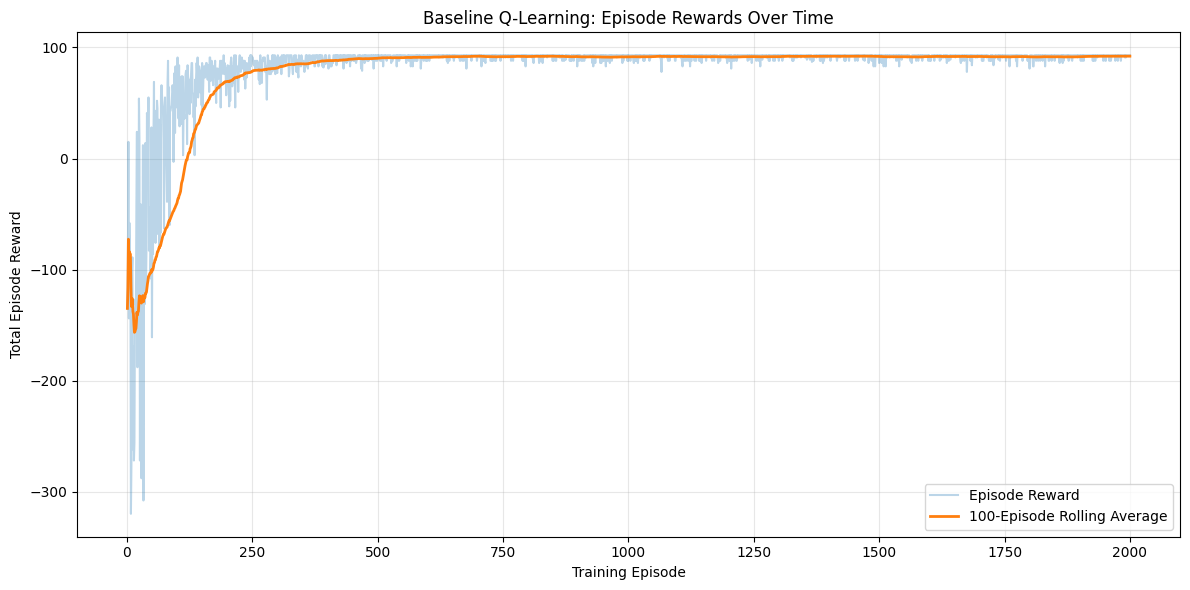

Reward plot saved to: C:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_2\Applied_Machine_Intelligence\Project_Q_Learning_Maze_Navigation\outputs\baseline_episode_rewards.png


In [15]:
# Create a reward-learning curve
plt.figure(figsize=(12, 6))

# Plot the reward earned in each episode
plt.plot(
    baseline_analysis["Episode"],
    baseline_analysis["Total_Reward"],
    alpha=0.30,
    label="Episode Reward"
)

# Plot the rolling average reward
plt.plot(
    baseline_analysis["Episode"],
    baseline_analysis["Rolling_Average_Reward"],
    linewidth=2,
    label=f"{ROLLING_WINDOW}-Episode Rolling Average"
)

# Add chart labels and formatting
plt.title("Baseline Q-Learning: Episode Rewards Over Time")
plt.xlabel("Training Episode")
plt.ylabel("Total Episode Reward")
plt.legend()
plt.grid(alpha=0.30)
plt.tight_layout()

# Save the visualization to the outputs folder
reward_plot_path = OUTPUT_DIR / "baseline_episode_rewards.png"
plt.savefig(
    reward_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Reward plot saved to: {reward_plot_path.resolve()}")

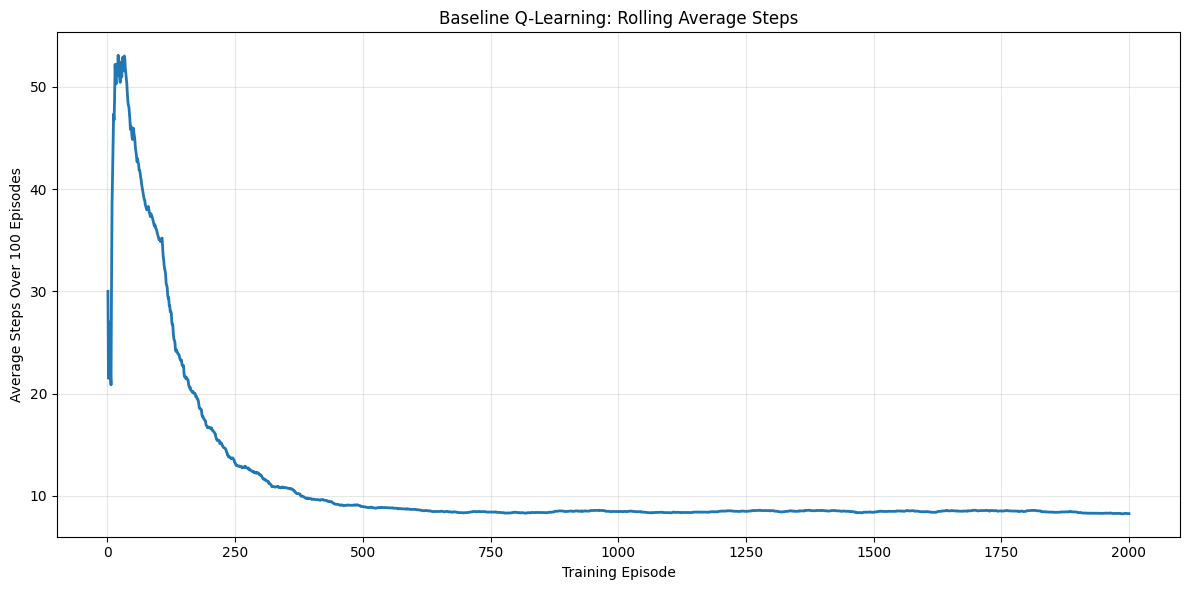

Steps plot saved to: C:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_2\Applied_Machine_Intelligence\Project_Q_Learning_Maze_Navigation\outputs\baseline_rolling_steps.png


In [16]:
# Plot the rolling average number of steps
plt.figure(figsize=(12, 6))

plt.plot(
    baseline_analysis["Episode"],
    baseline_analysis["Rolling_Average_Steps"],
    linewidth=2
)

plt.title("Baseline Q-Learning: Rolling Average Steps")
plt.xlabel("Training Episode")
plt.ylabel(f"Average Steps Over {ROLLING_WINDOW} Episodes")
plt.grid(alpha=0.30)
plt.tight_layout()

steps_plot_path = OUTPUT_DIR / "baseline_rolling_steps.png"

plt.savefig(
    steps_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Steps plot saved to: {steps_plot_path.resolve()}")

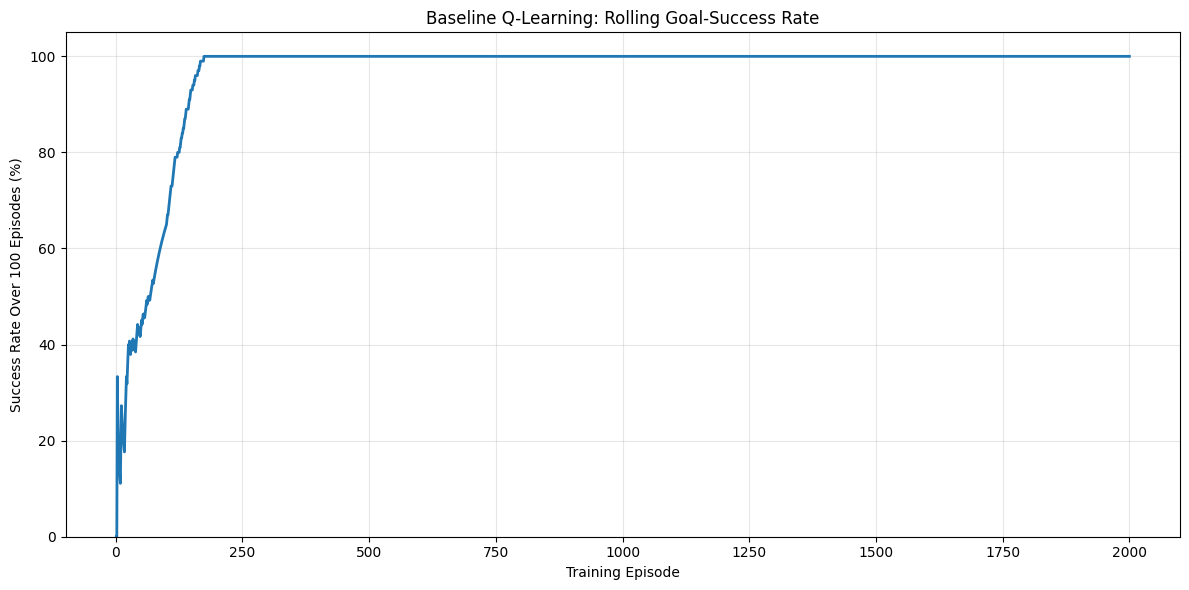

Success-rate plot saved to: C:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_2\Applied_Machine_Intelligence\Project_Q_Learning_Maze_Navigation\outputs\baseline_rolling_success_rate.png


In [17]:
# Plot the rolling goal-success rate
plt.figure(figsize=(12, 6))

plt.plot(
    baseline_analysis["Episode"],
    baseline_analysis["Rolling_Success_Rate"],
    linewidth=2
)

plt.title("Baseline Q-Learning: Rolling Goal-Success Rate")
plt.xlabel("Training Episode")
plt.ylabel(f"Success Rate Over {ROLLING_WINDOW} Episodes (%)")
plt.ylim(0, 105)
plt.grid(alpha=0.30)
plt.tight_layout()

success_plot_path = OUTPUT_DIR / "baseline_rolling_success_rate.png"

plt.savefig(
    success_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Success-rate plot saved to: {success_plot_path.resolve()}")

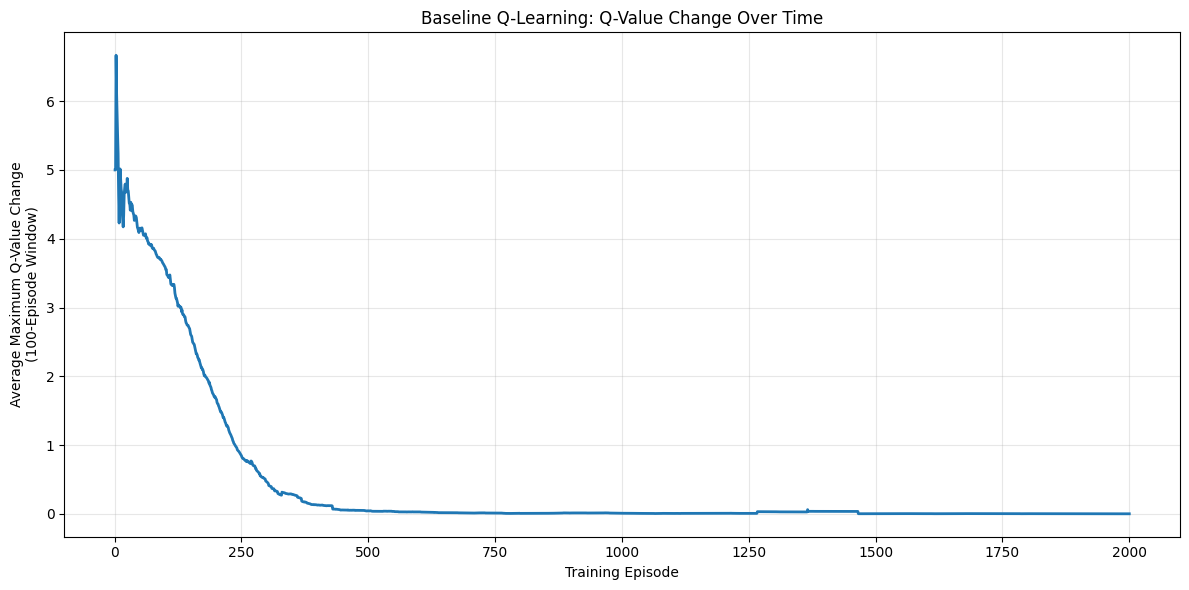

Q-value convergence plot saved to: C:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_2\Applied_Machine_Intelligence\Project_Q_Learning_Maze_Navigation\outputs\baseline_q_value_convergence.png


In [18]:
# Calculate a rolling average of the maximum Q-value change
baseline_analysis["Rolling_Average_Q_Change"] = (
    baseline_analysis["Maximum_Q_Change"]
    .rolling(window=ROLLING_WINDOW, min_periods=1)
    .mean()
)

# Plot Q-value changes over time
plt.figure(figsize=(12, 6))

plt.plot(
    baseline_analysis["Episode"],
    baseline_analysis["Rolling_Average_Q_Change"],
    linewidth=2
)

plt.title("Baseline Q-Learning: Q-Value Change Over Time")
plt.xlabel("Training Episode")
plt.ylabel(f"Average Maximum Q-Value Change\n({ROLLING_WINDOW}-Episode Window)")
plt.grid(alpha=0.30)
plt.tight_layout()

q_change_plot_path = OUTPUT_DIR / "baseline_q_value_convergence.png"

plt.savefig(
    q_change_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Q-value convergence plot saved to: {q_change_plot_path.resolve()}")

In [19]:
# Convert the trained Q-table into a labeled DataFrame
final_q_table_df = pd.DataFrame(
    baseline_q_table,
    index=[str(state) for state in VALID_STATES],
    columns=list(ACTIONS.values())
)

# Round the values for a cleaner display
final_q_table_display = final_q_table_df.round(3)

print("Final learned Q-table:")
display(final_q_table_display)

# Display the learned values for the starting state separately
start_state_q_values = final_q_table_df.loc[
    str(START_STATE)
].to_frame(name="Q-Value")

start_state_q_values.index.name = "Action"

print(f"\nQ-values for the start state {START_STATE}:")
display(start_state_q_values.round(3))

# Identify the action with the highest Q-value at the start state
best_start_action = start_state_q_values[
    "Q-Value"
].idxmax()

best_start_q_value = start_state_q_values[
    "Q-Value"
].max()

print(
    f"Best learned action from the start state: "
    f"{best_start_action}"
)

print(
    f"Highest start-state Q-value: "
    f"{best_start_q_value:.3f}"
)

Final learned Q-table:


,UP,DOWN,LEFT,RIGHT
"(0, 0)",-4.022,41.513,3.721,2.158
"(0, 2)",84.262,82.878,84.288,94.000
"(0, 3)",89.908,89.975,88.174,100.000
"(0, 4)",0.000,0.000,0.000,0.000
"(1, 0)",17.672,68.200,17.871,37.205
"(1, 2)",88.300,77.713,78.843,78.879
"(1, 4)",52.170,2.796,4.356,7.266
"(2, 0)",63.699,63.777,64.163,72.854
"(2, 1)",68.827,68.768,68.181,77.741
"(2, 2)",82.885,73.623,72.727,73.720



Q-values for the start state (4, 0):


,Q-Value
Action,
UP,63.800
DOWN,55.374
LEFT,55.396
RIGHT,55.093


Best learned action from the start state: UP
Highest start-state Q-value: 63.800


In [20]:
# Define arrow symbols for each action
ACTION_ARROWS = {
    0: "↑",  # UP
    1: "↓",  # DOWN
    2: "←",  # LEFT
    3: "→",  # RIGHT
}

# Store the best action for each nonterminal state
learned_policy = {}

for state in VALID_STATES:

    # Terminal states do not require an action
    if state in TERMINAL_STATES:
        continue

    state_index = STATE_TO_INDEX[state]

    # Select the action with the highest learned Q-value
    best_action = int(
        np.argmax(baseline_q_table[state_index])
    )

    learned_policy[state] = best_action

# Build a grid showing the learned policy
policy_display = []

for row in range(GRID_ROWS):
    display_row = []

    for column in range(GRID_COLUMNS):
        state = (row, column)

        if state == START_STATE:
            best_action = learned_policy[state]
            display_row.append(
                f"S {ACTION_ARROWS[best_action]}"
            )

        elif state == GOAL_STATE:
            display_row.append("G")

        elif state == TRAP_STATE:
            display_row.append("T")

        elif state in WALLS:
            display_row.append("#")

        else:
            best_action = learned_policy[state]
            display_row.append(
                ACTION_ARROWS[best_action]
            )

    policy_display.append(display_row)

# Convert the policy grid into a DataFrame
policy_df = pd.DataFrame(
    policy_display,
    index=[f"Row {row}" for row in range(GRID_ROWS)],
    columns=[f"Col {column}" for column in range(GRID_COLUMNS)]
)

print("Learned policy:")
print("↑ = UP, ↓ = DOWN, ← = LEFT, → = RIGHT")
print("S = Start, G = Goal, T = Trap, # = Wall")

display(policy_df)

# Create a detailed policy table
policy_records = []

for state, action in learned_policy.items():
    state_index = STATE_TO_INDEX[state]

    policy_records.append(
        {
            "State": state,
            "Best_Action": ACTIONS[action],
            "Policy_Symbol": ACTION_ARROWS[action],
            "Maximum_Q_Value": baseline_q_table[
                state_index,
                action
            ]
        }
    )

learned_policy_df = pd.DataFrame(policy_records)

learned_policy_df["Maximum_Q_Value"] = (
    learned_policy_df["Maximum_Q_Value"].round(3)
)

print("\nDetailed learned policy:")
display(learned_policy_df)

Learned policy:
↑ = UP, ↓ = DOWN, ← = LEFT, → = RIGHT
S = Start, G = Goal, T = Trap, # = Wall


,Col 0,Col 1,Col 2,Col 3,Col 4
Row 0,↓,#,→,→,G
Row 1,↓,#,↑,#,↑
Row 2,→,→,↑,#,↑
Row 3,↑,#,#,→,↑
Row 4,S ↑,←,←,↑,T



Detailed learned policy:


,State,Best_Action,Policy_Symbol,Maximum_Q_Value
0,"(0, 0)",DOWN,↓,41.513
1,"(0, 2)",RIGHT,→,94.000
2,"(0, 3)",RIGHT,→,100.000
3,"(1, 0)",DOWN,↓,68.200
4,"(1, 2)",UP,↑,88.300
5,"(1, 4)",UP,↑,52.170
6,"(2, 0)",RIGHT,→,72.854
7,"(2, 1)",RIGHT,→,77.741
8,"(2, 2)",UP,↑,82.885
9,"(2, 4)",UP,↑,20.334


In [21]:
def evaluate_learned_policy(
    q_values,
    start_state=START_STATE,
    maximum_steps=MAX_STEPS_PER_EPISODE
):
    """
    Evaluate the greedy policy learned from a trained Q-table.

    Parameters
    ----------
    q_values : numpy.ndarray
        Trained Q-table.
    start_state : tuple
        State from which evaluation begins.
    maximum_steps : int
        Maximum number of steps allowed during evaluation.

    Returns
    -------
    path : list
        Sequence of states visited by the agent.
    evaluation_history : pandas.DataFrame
        Step-by-step evaluation results.
    total_reward : float
        Total reward accumulated during evaluation.
    final_outcome : str
        Description of how the evaluation ended.
    """

    current_state = start_state
    path = [current_state]
    visited_states = {current_state}
    evaluation_records = []
    total_reward = 0
    final_outcome = "Maximum steps reached"

    for step in range(1, maximum_steps + 1):

        # Stop if evaluation somehow begins in a terminal state
        if current_state in TERMINAL_STATES:
            final_outcome = "Started in terminal state"
            break

        # Select the action with the highest learned Q-value
        current_state_index = STATE_TO_INDEX[current_state]

        best_action = int(
            np.argmax(q_values[current_state_index])
        )

        # Apply the selected action
        next_state, reward, done, outcome = take_action(
            current_state,
            best_action
        )

        total_reward += reward

        # Record the transition
        evaluation_records.append(
            {
                "Step": step,
                "Current_State": current_state,
                "Action": ACTIONS[best_action],
                "Next_State": next_state,
                "Reward": reward,
                "Outcome": outcome
            }
        )

        path.append(next_state)

        # Stop when the goal or trap is reached
        if done:
            final_outcome = outcome
            break

        # Detect a repeated state that indicates a policy loop
        if next_state in visited_states:
            final_outcome = "Policy loop detected"
            break

        visited_states.add(next_state)
        current_state = next_state

    evaluation_history = pd.DataFrame(evaluation_records)

    return path, evaluation_history, total_reward, final_outcome


# Evaluate the baseline learned policy
learned_path, policy_evaluation_df, policy_total_reward, policy_outcome = (
    evaluate_learned_policy(
        q_values=baseline_q_table
    )
)

# Display the step-by-step path
print("Greedy policy evaluation:")
display(policy_evaluation_df)

print(f"Final outcome: {policy_outcome}")
print(f"Number of actions: {len(policy_evaluation_df)}")
print(f"Total reward: {policy_total_reward}")
print(f"Path: {learned_path}")

Greedy policy evaluation:


,Step,Current_State,Action,Next_State,Reward,Outcome
0,1,"(4, 0)",UP,"(3, 0)",-1,Valid move
1,2,"(3, 0)",UP,"(2, 0)",-1,Valid move
2,3,"(2, 0)",RIGHT,"(2, 1)",-1,Valid move
3,4,"(2, 1)",RIGHT,"(2, 2)",-1,Valid move
4,5,"(2, 2)",UP,"(1, 2)",-1,Valid move
5,6,"(1, 2)",UP,"(0, 2)",-1,Valid move
6,7,"(0, 2)",RIGHT,"(0, 3)",-1,Valid move
7,8,"(0, 3)",RIGHT,"(0, 4)",100,Goal reached


Final outcome: Goal reached
Number of actions: 8
Total reward: 93
Path: [(4, 0), (3, 0), (2, 0), (2, 1), (2, 2), (1, 2), (0, 2), (0, 3), (0, 4)]


In [22]:
# Create a mapping from each visited state to its path position
path_step_mapping = {
    state: step_number
    for step_number, state in enumerate(learned_path)
}

# Build a grid showing the learned route
path_display = []

for row in range(GRID_ROWS):
    display_row = []

    for column in range(GRID_COLUMNS):
        state = (row, column)

        if state == START_STATE:
            display_row.append("S")

        elif state == GOAL_STATE:
            display_row.append("G")

        elif state == TRAP_STATE:
            display_row.append("T")

        elif state in WALLS:
            display_row.append("#")

        elif state in path_step_mapping:
            display_row.append(
                str(path_step_mapping[state])
            )

        else:
            display_row.append(".")

    path_display.append(display_row)

# Convert the path grid into a DataFrame
learned_path_df = pd.DataFrame(
    path_display,
    index=[f"Row {row}" for row in range(GRID_ROWS)],
    columns=[f"Col {column}" for column in range(GRID_COLUMNS)]
)

print("Learned maze-navigation path:")
print("S = Start, G = Goal, T = Trap, # = Wall")
print("Numbers indicate the order of intermediate states.")

display(learned_path_df)

Learned maze-navigation path:
S = Start, G = Goal, T = Trap, # = Wall
Numbers indicate the order of intermediate states.


,Col 0,Col 1,Col 2,Col 3,Col 4
Row 0,.,#,6,7,G
Row 1,.,#,5,#,.
Row 2,2,3,4,#,.
Row 3,1,#,#,.,.
Row 4,S,.,.,.,T


In [23]:
# Define the hyperparameter configurations to compare
experiment_configurations = {
    "Baseline": {
        "learning_rate": 0.10,
        "discount_factor": 0.95,
        "initial_epsilon": 1.00,
        "minimum_epsilon": 0.05,
        "epsilon_decay": 0.995
    },
    "Low Learning Rate": {
        "learning_rate": 0.05,
        "discount_factor": 0.95,
        "initial_epsilon": 1.00,
        "minimum_epsilon": 0.05,
        "epsilon_decay": 0.995
    },
    "High Learning Rate": {
        "learning_rate": 0.50,
        "discount_factor": 0.95,
        "initial_epsilon": 1.00,
        "minimum_epsilon": 0.05,
        "epsilon_decay": 0.995
    },
    "Low Discount Factor": {
        "learning_rate": 0.10,
        "discount_factor": 0.70,
        "initial_epsilon": 1.00,
        "minimum_epsilon": 0.05,
        "epsilon_decay": 0.995
    },
    "Fast Epsilon Decay": {
        "learning_rate": 0.10,
        "discount_factor": 0.95,
        "initial_epsilon": 1.00,
        "minimum_epsilon": 0.05,
        "epsilon_decay": 0.980
    },
    "Slow Epsilon Decay": {
        "learning_rate": 0.10,
        "discount_factor": 0.95,
        "initial_epsilon": 1.00,
        "minimum_epsilon": 0.05,
        "epsilon_decay": 0.999
    }
}

# Convert the configurations into a DataFrame for display
experiment_configuration_df = pd.DataFrame(
    experiment_configurations
).T

experiment_configuration_df.index.name = "Configuration"

display(experiment_configuration_df)

print(
    f"Number of hyperparameter configurations: "
    f"{len(experiment_configurations)}"
)

,learning_rate,discount_factor,initial_epsilon,minimum_epsilon,epsilon_decay
Configuration,,,,,
Baseline,0.10,0.95,1.0,0.05,0.995
Low Learning Rate,0.05,0.95,1.0,0.05,0.995
High Learning Rate,0.50,0.95,1.0,0.05,0.995
Low Discount Factor,0.10,0.70,1.0,0.05,0.995
Fast Epsilon Decay,0.10,0.95,1.0,0.05,0.980
Slow Epsilon Decay,0.10,0.95,1.0,0.05,0.999


Number of hyperparameter configurations: 6


In [24]:
# Store the trained models and histories for later analysis
experiment_results = {}

# Store one summary record for each configuration
experiment_summary_records = []

# Train and evaluate every hyperparameter configuration
for configuration_name, parameters in experiment_configurations.items():

    # Train a new agent using the current configuration
    experiment_q_table, experiment_history = train_q_learning(
        learning_rate=parameters["learning_rate"],
        discount_factor=parameters["discount_factor"],
        initial_epsilon=parameters["initial_epsilon"],
        minimum_epsilon=parameters["minimum_epsilon"],
        epsilon_decay=parameters["epsilon_decay"],
        number_of_episodes=NUM_EPISODES,
        maximum_steps=MAX_STEPS_PER_EPISODE,
        random_seed=RANDOM_SEED
    )

    # Create analysis columns for rolling performance
    experiment_history = experiment_history.copy()

    experiment_history["Success"] = (
        experiment_history["Goal_Reached"].astype(int)
    )

    experiment_history["Rolling_Success_Rate"] = (
        experiment_history["Success"]
        .rolling(window=ROLLING_WINDOW, min_periods=1)
        .mean()
        * 100
    )

    experiment_history["Rolling_Average_Reward"] = (
        experiment_history["Total_Reward"]
        .rolling(window=ROLLING_WINDOW, min_periods=1)
        .mean()
    )

    experiment_history["Rolling_Average_Q_Change"] = (
        experiment_history["Maximum_Q_Change"]
        .rolling(window=ROLLING_WINDOW, min_periods=1)
        .mean()
    )

    # Separate the early and late portions of training
    first_100 = experiment_history.head(100)
    last_100 = experiment_history.tail(100)

    # Find the first episode where rolling success reaches 90%
    success_threshold_rows = experiment_history[
        experiment_history["Rolling_Success_Rate"] >= 90
    ]

    if success_threshold_rows.empty:
        episode_to_90_percent_success = np.nan
    else:
        episode_to_90_percent_success = int(
            success_threshold_rows["Episode"].iloc[0]
        )

    # Evaluate the final greedy policy without exploration
    (
        experiment_path,
        experiment_evaluation,
        experiment_policy_reward,
        experiment_policy_outcome
    ) = evaluate_learned_policy(
        q_values=experiment_q_table
    )

    # Save the complete results for later plotting
    experiment_results[configuration_name] = {
        "Q_Table": experiment_q_table,
        "History": experiment_history,
        "Path": experiment_path,
        "Evaluation": experiment_evaluation,
        "Policy_Outcome": experiment_policy_outcome,
        "Policy_Reward": experiment_policy_reward
    }

    # Create one summary record
    experiment_summary_records.append(
        {
            "Configuration": configuration_name,
            "Learning_Rate": parameters["learning_rate"],
            "Discount_Factor": parameters["discount_factor"],
            "Epsilon_Decay": parameters["epsilon_decay"],
            "Overall_Success_Rate_Pct": (
                experiment_history["Goal_Reached"].mean() * 100
            ),
            "First_100_Avg_Reward": (
                first_100["Total_Reward"].mean()
            ),
            "Last_100_Avg_Reward": (
                last_100["Total_Reward"].mean()
            ),
            "First_100_Success_Rate_Pct": (
                first_100["Goal_Reached"].mean() * 100
            ),
            "Last_100_Success_Rate_Pct": (
                last_100["Goal_Reached"].mean() * 100
            ),
            "Last_100_Avg_Steps": (
                last_100["Steps"].mean()
            ),
            "Episode_to_90_Pct_Success": (
                episode_to_90_percent_success
            ),
            "Final_Rolling_Q_Change": (
                experiment_history[
                    "Rolling_Average_Q_Change"
                ].iloc[-1]
            ),
            "Greedy_Policy_Outcome": experiment_policy_outcome,
            "Greedy_Policy_Steps": len(experiment_evaluation),
            "Greedy_Policy_Reward": experiment_policy_reward
        }
    )

# Convert the experiment summaries into a DataFrame
experiment_summary_df = pd.DataFrame(
    experiment_summary_records
)

# Round numeric columns for a cleaner display
numeric_columns = experiment_summary_df.select_dtypes(
    include=np.number
).columns

experiment_summary_df[numeric_columns] = (
    experiment_summary_df[numeric_columns].round(3)
)

print("Hyperparameter experiment summary:")
display(experiment_summary_df)

Hyperparameter experiment summary:


,Configuration,Learning_Rate,Discount_Factor,Epsilon_Decay,Overall_Success_Rate_Pct,First_100_Avg_Reward,Last_100_Avg_Reward,First_100_Success_Rate_Pct,Last_100_Success_Rate_Pct,Last_100_Avg_Steps,Episode_to_90_Pct_Success,Final_Rolling_Q_Change,Greedy_Policy_Outcome,Greedy_Policy_Steps,Greedy_Policy_Reward
0,Baseline,0.10,0.95,0.995,98.25,-39.90,92.18,65.0,100.0,8.26,144,0.002,Goal reached,8,93
1,Low Learning Rate,0.05,0.95,0.995,97.10,-60.17,92.03,44.0,100.0,8.29,180,0.078,Goal reached,8,93
2,High Learning Rate,0.50,0.95,0.995,98.95,-31.66,92.16,79.0,100.0,8.28,113,0.000,Goal reached,8,93
3,Low Discount Factor,0.10,0.70,0.995,97.85,-42.88,91.98,57.0,100.0,8.30,156,0.001,Goal reached,8,93
4,Fast Epsilon Decay,0.10,0.95,0.980,99.15,38.39,92.02,84.0,100.0,8.42,110,0.140,Goal reached,8,93
5,Slow Epsilon Decay,0.10,0.95,0.999,95.15,-145.65,89.64,38.0,100.0,9.28,280,0.000,Goal reached,8,93


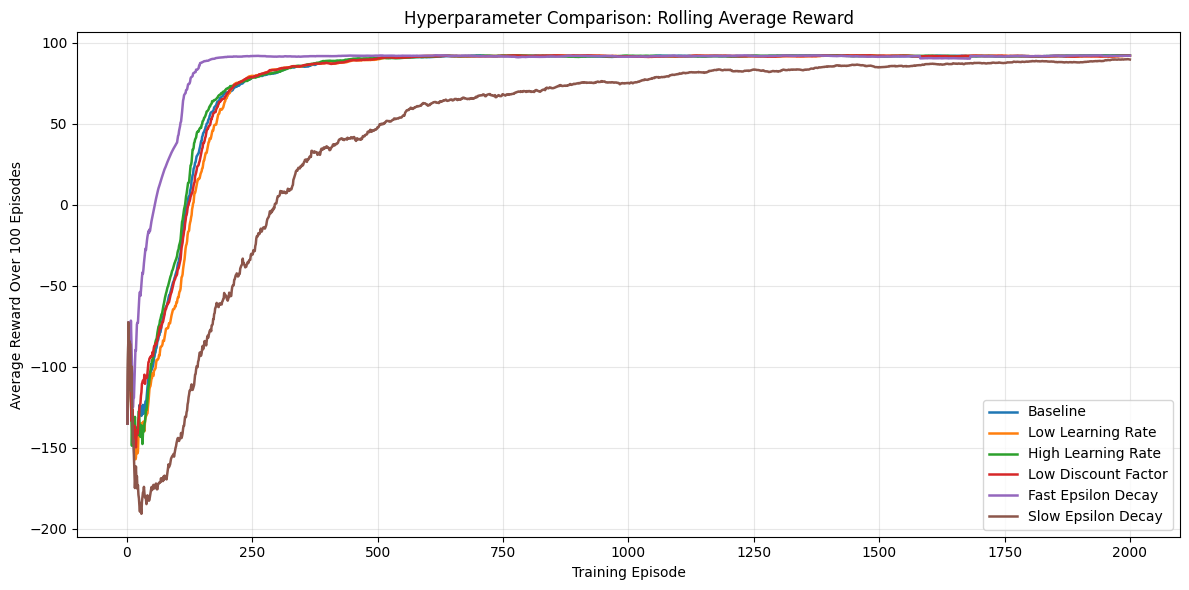

Reward comparison plot saved to: C:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_2\Applied_Machine_Intelligence\Project_Q_Learning_Maze_Navigation\outputs\hyperparameter_reward_comparison.png


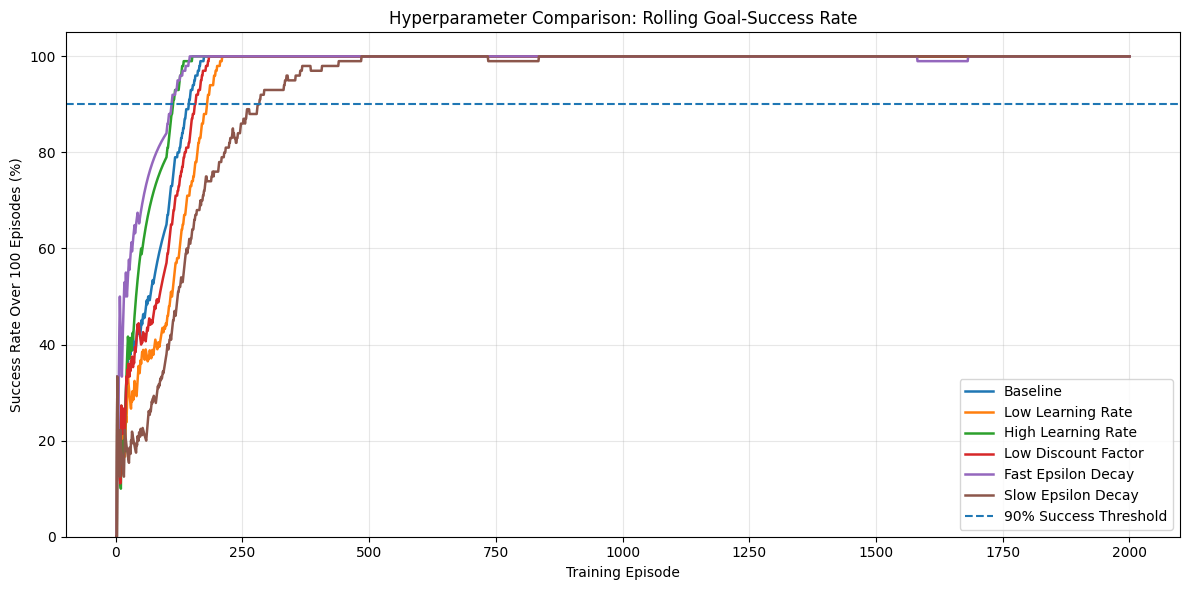

Success comparison plot saved to: C:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_2\Applied_Machine_Intelligence\Project_Q_Learning_Maze_Navigation\outputs\hyperparameter_success_comparison.png


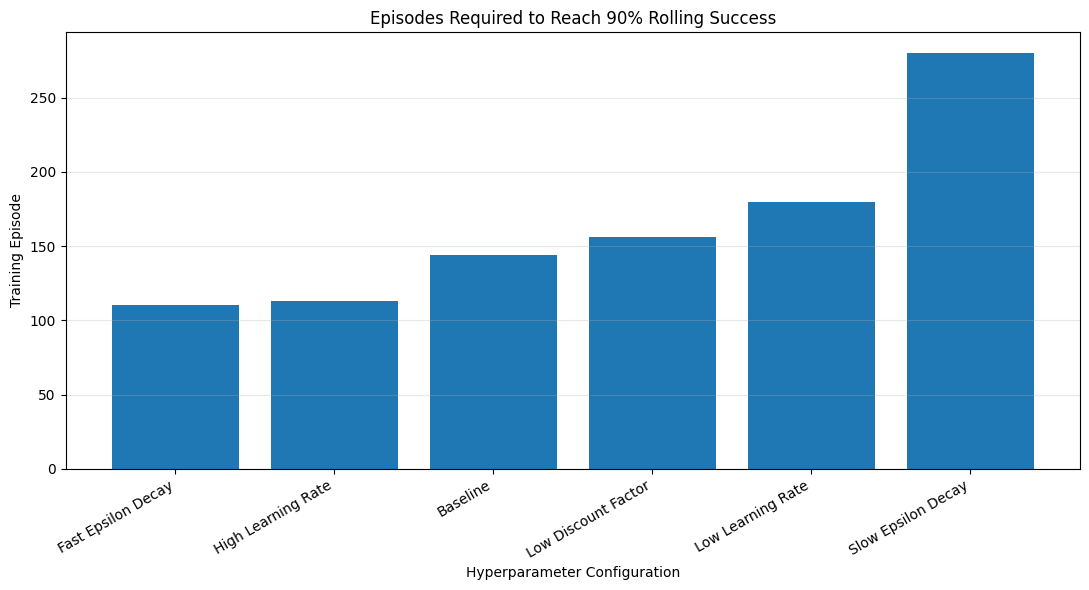

Convergence comparison plot saved to: C:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_2\Applied_Machine_Intelligence\Project_Q_Learning_Maze_Navigation\outputs\hyperparameter_convergence_speed.png


In [25]:
# Plot rolling average rewards for all configurations
plt.figure(figsize=(12, 6))

for configuration_name, results in experiment_results.items():
    history = results["History"]

    plt.plot(
        history["Episode"],
        history["Rolling_Average_Reward"],
        linewidth=1.8,
        label=configuration_name
    )

plt.title("Hyperparameter Comparison: Rolling Average Reward")
plt.xlabel("Training Episode")
plt.ylabel(f"Average Reward Over {ROLLING_WINDOW} Episodes")
plt.legend()
plt.grid(alpha=0.30)
plt.tight_layout()

reward_comparison_path = (
    OUTPUT_DIR / "hyperparameter_reward_comparison.png"
)

plt.savefig(
    reward_comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Reward comparison plot saved to: "
    f"{reward_comparison_path.resolve()}"
)


# Plot rolling success rates for all configurations
plt.figure(figsize=(12, 6))

for configuration_name, results in experiment_results.items():
    history = results["History"]

    plt.plot(
        history["Episode"],
        history["Rolling_Success_Rate"],
        linewidth=1.8,
        label=configuration_name
    )

plt.axhline(
    y=90,
    linestyle="--",
    linewidth=1.5,
    label="90% Success Threshold"
)

plt.title("Hyperparameter Comparison: Rolling Goal-Success Rate")
plt.xlabel("Training Episode")
plt.ylabel(f"Success Rate Over {ROLLING_WINDOW} Episodes (%)")
plt.ylim(0, 105)
plt.legend()
plt.grid(alpha=0.30)
plt.tight_layout()

success_comparison_path = (
    OUTPUT_DIR / "hyperparameter_success_comparison.png"
)

plt.savefig(
    success_comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Success comparison plot saved to: "
    f"{success_comparison_path.resolve()}"
)


# Prepare convergence-speed data
convergence_speed_df = experiment_summary_df[
    [
        "Configuration",
        "Episode_to_90_Pct_Success"
    ]
].copy()

convergence_speed_df = convergence_speed_df.sort_values(
    by="Episode_to_90_Pct_Success"
)

# Plot episodes needed to reach 90% success
plt.figure(figsize=(11, 6))

plt.bar(
    convergence_speed_df["Configuration"],
    convergence_speed_df["Episode_to_90_Pct_Success"]
)

plt.title("Episodes Required to Reach 90% Rolling Success")
plt.xlabel("Hyperparameter Configuration")
plt.ylabel("Training Episode")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.30)
plt.tight_layout()

convergence_comparison_path = (
    OUTPUT_DIR / "hyperparameter_convergence_speed.png"
)

plt.savefig(
    convergence_comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Convergence comparison plot saved to: "
    f"{convergence_comparison_path.resolve()}"
)

In [26]:
# Define paths for the output tables
training_history_path = OUTPUT_DIR / "baseline_training_history.csv"
q_table_path = OUTPUT_DIR / "final_q_table.csv"
policy_path = OUTPUT_DIR / "learned_policy.csv"
policy_evaluation_path = OUTPUT_DIR / "greedy_policy_evaluation.csv"
performance_comparison_path = OUTPUT_DIR / "baseline_performance_comparison.csv"
experiment_summary_path = OUTPUT_DIR / "hyperparameter_experiment_summary.csv"

# Save the baseline training history
baseline_analysis.to_csv(
    training_history_path,
    index=False
)

# Save the final learned Q-table
final_q_table_df.to_csv(
    q_table_path,
    index_label="State"
)

# Save the learned policy
learned_policy_df.to_csv(
    policy_path,
    index=False
)

# Save the step-by-step greedy-policy evaluation
policy_evaluation_df.to_csv(
    policy_evaluation_path,
    index=False
)

# Save the early-versus-late performance comparison
performance_comparison.to_csv(
    performance_comparison_path,
    index=False
)

# Save the hyperparameter comparison results
experiment_summary_df.to_csv(
    experiment_summary_path,
    index=False
)

# Display all files currently saved in the outputs folder
saved_output_files = sorted(
    file_path.name
    for file_path in OUTPUT_DIR.iterdir()
    if file_path.is_file()
)

print("Project output files saved successfully:")

for file_name in saved_output_files:
    print(f"- {file_name}")

print(f"\nTotal output files: {len(saved_output_files)}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Project output files saved successfully:
- baseline_episode_rewards.png
- baseline_performance_comparison.csv
- baseline_q_value_convergence.png
- baseline_rolling_steps.png
- baseline_rolling_success_rate.png
- baseline_training_history.csv
- final_q_table.csv
- greedy_policy_evaluation.csv
- hyperparameter_convergence_speed.png
- hyperparameter_experiment_summary.csv
- hyperparameter_reward_comparison.png
- hyperparameter_success_comparison.png
- learned_policy.csv

Total output files: 13
Output directory: C:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_2\Applied_Machine_Intelligence\Project_Q_Learning_Maze_Navigation\outputs


## Project Results and Conclusion

This project successfully implemented Q-learning for navigation in a 5 × 5 grid-based maze. The environment contained a starting state, a goal state, a trap, blocked cells, four movement actions, and a reward system that encouraged the agent to reach the goal efficiently while avoiding invalid moves and the trap.

The agent learned through repeated interaction with the environment. An epsilon-greedy strategy was used to balance exploration and exploitation. At the beginning of training, the agent explored frequently because epsilon was initialized at 1.0. Epsilon gradually decreased to a minimum of 0.05, allowing the agent to increasingly rely on the actions with the highest learned Q-values.

The baseline model used a learning rate of 0.10, a discount factor of 0.95, an epsilon decay rate of 0.995, and 2,000 training episodes. The agent achieved an overall training success rate of 98.25%. Its performance improved from a 65% goal-success rate during the first 100 episodes to a 100% success rate during the final 100 episodes.

The learned greedy policy successfully navigated from the start state at `(4, 0)` to the goal state at `(0, 4)` in eight actions. The agent received a total evaluation reward of 93, consisting of seven regular movement penalties of −1 followed by the goal reward of +100. Eight actions represent the shortest possible route between the start and goal locations in this maze.

The final Q-table also reflected the expected behavior. At the start state, the `UP` action had the highest Q-value, directing the agent toward the optimal route. At state `(0, 3)`, moving `RIGHT` had a Q-value of 100 because it immediately reached the goal. In contrast, moving `RIGHT` from `(4, 3)` had a strongly negative Q-value because it entered the trap.

Hyperparameter experiments showed that all six tested configurations eventually learned the same optimal eight-step policy. However, the settings affected learning speed and convergence. Fast epsilon decay reached a 90% rolling success rate earliest, at episode 110, but retained greater late-stage Q-value variation. The high learning rate reached the threshold at episode 113 and showed stable final Q-values. The low learning rate required 180 episodes, demonstrating slower value updates. Slow epsilon decay required 280 episodes because the agent continued exploring for a longer period.

Overall, the results demonstrate that Q-learning can learn an optimal maze-navigation policy without being given the correct path in advance. The agent improved through rewards, penalties, exploration, and repeated Q-value updates. The experiment also showed that hyperparameters influence how quickly and smoothly learning occurs, even when the final learned policy is the same.
